## Задача


\begin{cases}
\dfrac{dx}{dt} = x \left( 1 - 0.5x - \dfrac{2}{7} \alpha_2^{-2} y \right), \quad x(0) = x_0, \\[10pt]
\dfrac{dy}{dt} = y \left( 2\alpha_2 - 0.5y - 3.5\alpha_2^2 x \right), \quad y(0) = y_0, \\[10pt]
\dfrac{d\alpha_2}{dt} = \varepsilon (2 - 7\alpha_2 x), \quad \alpha_2(0) = \alpha_{20}; \quad t \in [0; T_k].
\end{cases}

#### Рекомендуемые значения начальных данных


$0 \le x_0 \le 3$,

 $0 \le y_0 \le 15$

 $\alpha_{20}$ близко к нулю, например,
можно положить $\alpha_{20} = 0.0001$;

 $T_k = 1500$.

$\varepsilon \le 0.01$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d


    ЧИСЛЕННОЕ МОДЕЛИРОВАНИЕ ЭКОГЕНЕТИЧЕСКОЙ МОДЕЛИ
               Сравнение явного и неявного метода Эйлера

1. ПРОВЕРКА УСТОЙЧИВОСТИ МЕТОДОВ

h            Явный Эйлер        Неявный Эйлер     
--------------------------------------------------
⚠️ Явный метод разошёлся при t ≈ 0.100
⚠️ Неявный метод: NaN при t ≈ 0.100
1e-01        ❌ РАСХОД           ✅ УСТОЙЧИВ        
⚠️ Явный метод разошёлся при t ≈ 0.050
⚠️ Неявный метод: NaN при t ≈ 0.050
5e-02        ❌ РАСХОД           ✅ УСТОЙЧИВ        
⚠️ Явный метод разошёлся при t ≈ 0.010
⚠️ Неявный метод: NaN при t ≈ 0.010
1e-02        ❌ РАСХОД           ✅ УСТОЙЧИВ        
⚠️ Явный метод разошёлся при t ≈ 0.005
⚠️ Неявный метод: NaN при t ≈ 0.005
5e-03        ❌ РАСХОД           ✅ УСТОЙЧИВ        
⚠️ Явный метод разошёлся при t ≈ 0.001
⚠️ Неявный метод: NaN при t ≈ 0.001
1e-03        ✅ УСТОЙЧИВ         ✅ УСТОЙЧИВ        
⚠️ Явный метод разошёлся при t ≈ 0.001
⚠️ Неявный метод: NaN при t ≈ 0.001
5e-04        ✅ УСТОЙЧИВ         ✅ УСТОЙЧИВ       

/tmp/ipykernel_199/3071517694.py:11: RuntimeWarning: overflow encountered in scalar multiply
  dydt = y * (2 * a2_safe - 0.5 * y - 3.5 * (a2_safe**2) * x)
/tmp/ipykernel_199/3071517694.py:10: RuntimeWarning: invalid value encountered in scalar multiply
  dxdt = x * (1 - 0.5 * x - (2/7) * (a2_safe**(-2)) * y)
/tmp/ipykernel_199/3071517694.py:11: RuntimeWarning: overflow encountered in scalar power
  dydt = y * (2 * a2_safe - 0.5 * y - 3.5 * (a2_safe**2) * x)
/tmp/ipykernel_199/3071517694.py:11: RuntimeWarning: invalid value encountered in scalar subtract
  dydt = y * (2 * a2_safe - 0.5 * y - 3.5 * (a2_safe**2) * x)
/tmp/ipykernel_199/3071517694.py:12: RuntimeWarning: overflow encountered in scalar multiply
  da2dt = epsilon * (2 - 7 * a2_safe * x)


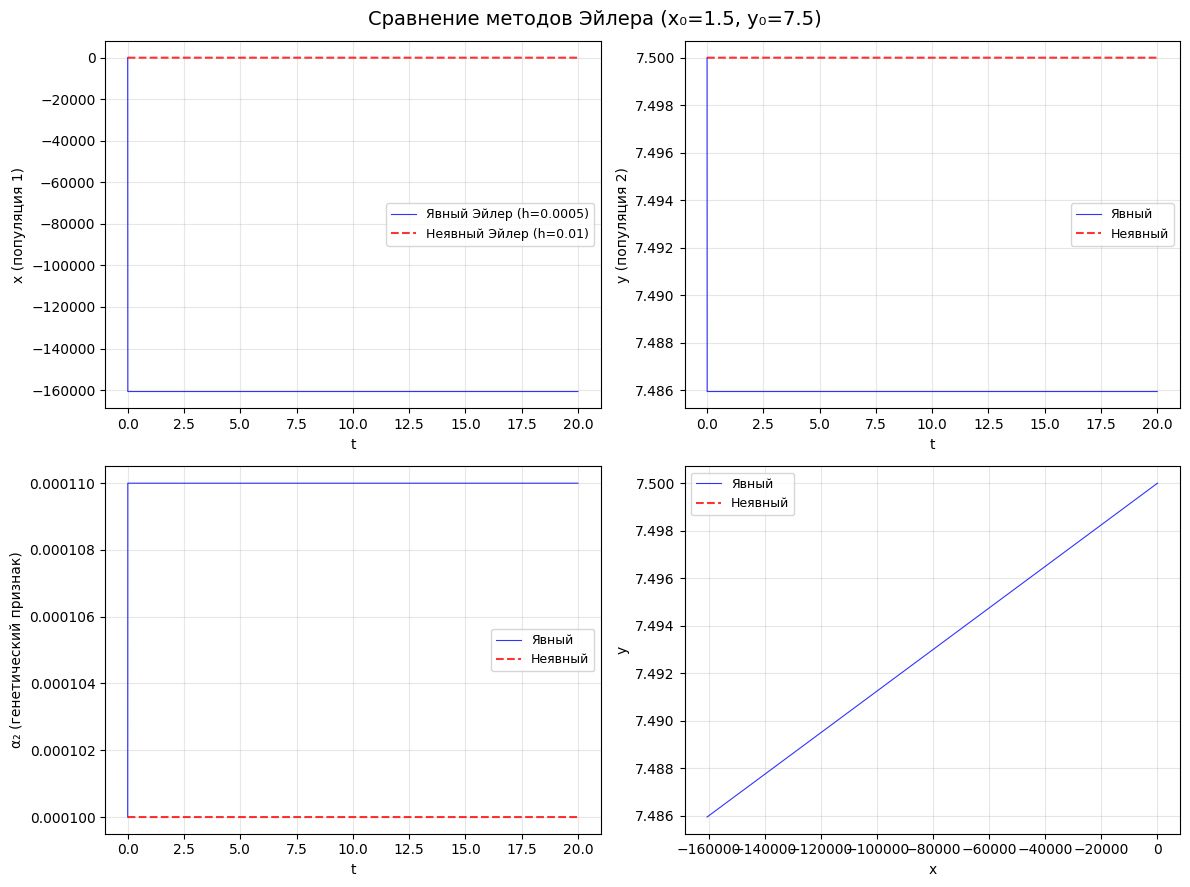


=== РЕЗУЛЬТАТЫ ПРИ t=20 ===
Явный:   x=-160712.7855, y=7.4859, α₂=0.000110
Неявный: x=1.5000, y=7.5000, α₂=0.000100
Отличие: Δx=160714.2855, Δy=0.0141

4. ЗАВИСИМОСТЬ ОТ ПАРАМЕТРА ε
⚠️ Неявный метод: NaN при t ≈ 0.010
ε = 0.001: x_конечн=1.5000, y_конечн=7.5000, α₂_конечн=0.000100
⚠️ Неявный метод: NaN при t ≈ 0.010
ε = 0.005: x_конечн=1.5000, y_конечн=7.5000, α₂_конечн=0.000100
⚠️ Неявный метод: NaN при t ≈ 0.010
ε = 0.010: x_конечн=1.5000, y_конечн=7.5000, α₂_конечн=0.000100
⚠️ Неявный метод: NaN при t ≈ 0.010
ε = 0.020: x_конечн=1.5000, y_конечн=7.5000, α₂_конечн=0.000100
⚠️ Неявный метод: NaN при t ≈ 0.010
ε = 0.050: x_конечн=1.5000, y_конечн=7.5000, α₂_конечн=0.000100
⚠️ Неявный метод: NaN при t ≈ 0.010
ε = 0.100: x_конечн=1.5000, y_конечн=7.5000, α₂_конечн=0.000100


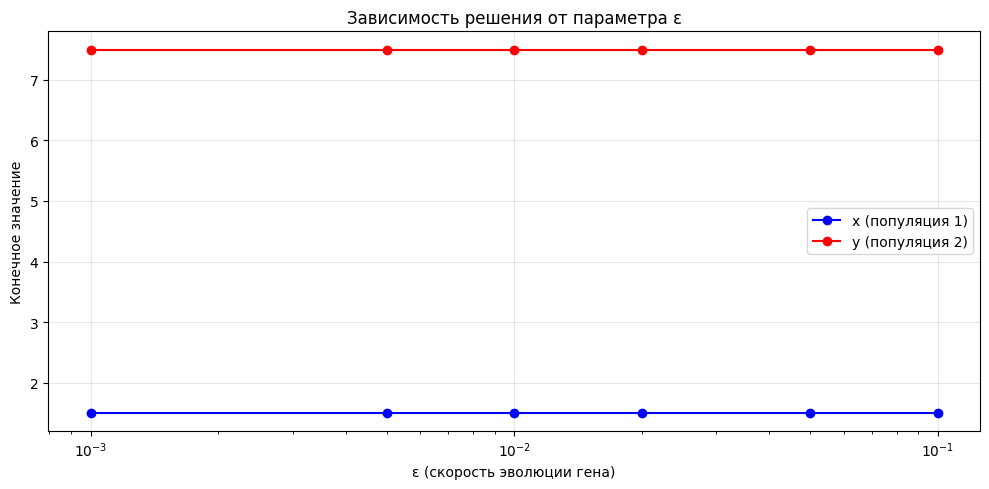


5. ИТОГОВЫЕ ТАБЛИЦЫ

--- Таблица устойчивости ---
     h  explicit  implicit
0.1000     False      True
0.0500     False      True
0.0100     False      True
0.0050     False      True
0.0010      True      True
0.0005      True      True
0.0001      True      True

--- Сравнение методов ---
 x₀   y₀        x_явн   y_явн x_неявн y_неявн           Δx
1.5  7.5 -160712.7855  7.4859  1.5000  7.5000  160714.2855
0.5  2.0  -14285.2141  1.9990  0.5000  2.0000   14285.7141
2.5 12.0 -428568.9289 11.9640  2.5000 12.0000  428571.4289
0.1  0.5 4214630.2517  0.4999  0.1000  0.5000 4214630.1517
3.0 15.0 -642854.1436 14.9438  3.0000 15.0000  642857.1436

--- Зависимость от ε ---
    ε  x_конечн  y_конечн  α₂_конечн
0.001       1.5       7.5     0.0001
0.005       1.5       7.5     0.0001
0.010       1.5       7.5     0.0001
0.020       1.5       7.5     0.0001
0.050       1.5       7.5     0.0001
0.100       1.5       7.5     0.0001


In [2]:
# Система (модель 1)

def system_safe(t, v, epsilon=0.01):

    x, y, a2 = v

    # ограничение alpha2 снизу
    a2_safe = max(a2, 1e-6)

    dxdt = x * (1 - 0.5 * x - (2/7) * (a2_safe**(-2)) * y)
    dydt = y * (2 * a2_safe - 0.5 * y - 3.5 * (a2_safe**2) * x)
    da2dt = epsilon * (2 - 7 * a2_safe * x)

    return np.array([dxdt, dydt, da2dt])



# Явный метод Эйлера
def euler_explicit(f, y0, t_span, h):
    t_start, t_end = t_span
    t = np.arange(t_start, t_end + h, h)
    y = np.zeros((len(t), len(y0)))
    y[0] = y0

    for i in range(len(t) - 1):
        y[i+1] = y[i] + h * f(t[i], y[i])


        if np.any(np.isnan(y[i+1])) or np.any(np.abs(y[i+1]) > 1e8):
            print(f"⚠️ Явный метод разошёлся при t ≈ {t[i]:.3f}")
            y[i+1:] = y[i]  # заполняем последним корректным значением
            break

    return t, y



# Неявный метод Эйлера
def implicit_euler(f, y0, t_span, h, tol=1e-3, max_iter=30):
    """
    Неявный метод Эйлера с релаксацией для устойчивости.
    Для жёстких систем требует меньше итераций.
    """
    t_start, t_end = t_span
    t = np.arange(t_start, t_end + h, h)
    y = np.zeros((len(t), len(y0)))
    y[0] = y0

    for i in range(len(t) - 1):
        # Предиктор: явный Эйлер
        y_guess = y[i] + h * f(t[i], y[i])

        # Корректор: простая итерация с релаксацией
        for _ in range(max_iter):
            f_next = f(t[i+1], y_guess)
            y_new = y[i] + h * f_next

            # Проверка на расходимость
            if np.any(np.isnan(y_new)):
                print(f"⚠️ Неявный метод: NaN при t ≈ {t[i+1]:.3f}")
                y[i+1:] = y[i]
                return t, y

            diff = np.linalg.norm(y_new - y_guess)
            if diff < tol:
                break
            y_guess = 0.8 * y_guess + 0.2 * y_new  # релаксация

        y[i+1] = y_new

    return t, y



# 1. Проверка устойчивости
def stability_check():
    """
    Проверяет, при каких шагах h методы устойчивы.
    """
    print("\n" + "=" * 60)
    print("1. ПРОВЕРКА УСТОЙЧИВОСТИ МЕТОДОВ")
    print("=" * 60)

    y0 = [1.5, 7.5, 0.0001]
    t_span = [0, 5]  # короткий интервал

    h_values = [0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]

    results = []

    print(f"\n{'h':<12} {'Явный Эйлер':<18} {'Неявный Эйлер':<18}")
    print("-" * 50)

    for h in h_values:
        # Явный метод
        t, y = euler_explicit(system_safe, y0, t_span, h)
        exp_ok = np.all(np.isfinite(y)) and np.max(np.abs(y)) < 1e6

        # Неявный метод
        t, y = implicit_euler(system_safe, y0, t_span, h)
        imp_ok = np.all(np.isfinite(y)) and np.max(np.abs(y)) < 1e6

        status_exp = "✅ УСТОЙЧИВ" if exp_ok else "❌ РАСХОД"
        status_imp = "✅ УСТОЙЧИВ" if imp_ok else "❌ РАСХОД"

        print(f"{h:<12.0e} {status_exp:<18} {status_imp:<18}")
        results.append({'h': h, 'explicit': exp_ok, 'implicit': imp_ok})

    return pd.DataFrame(results)



# 2. Сравнение методов для разных начальных условий
def compare_methods():
    """
    Сравнивает явный и неявный метод Эйлера для разных (x0, y0).
    """
    print("\n" + "=" * 60)
    print("2. СРАВНЕНИЕ МЕТОДОВ ЭЙЛЕРА")
    print("=" * 60)

    # Набор начальных условий из условия задачи
    test_cases = [
        (1.5, 7.5, "Стандартный случай"),
        (0.5, 2.0, "Малые популяции"),
        (2.5, 12.0, "Большие популяции"),
        (0.1, 0.5, "Очень малые"),
        (3.0, 15.0, "Граничные значения"),
    ]

    t_span = [0, 20]
    h_exp = 0.0005
    h_imp = 0.01

    rows = []

    for x0, y0, desc in test_cases:
        print(f"\n--- {desc}: x₀={x0}, y₀={y0} ---")
        y0_vec = [x0, y0, 0.0001]

        # Явный метод
        t_exp, y_exp = euler_explicit(system_safe, y0_vec, t_span, h_exp)
        if np.all(np.isfinite(y_exp)):
            print(f"  Явный (h={h_exp}): x={y_exp[-1,0]:.4f}, y={y_exp[-1,1]:.4f}, α₂={y_exp[-1,2]:.6f}")
            x_exp, y_exp_val, a_exp = y_exp[-1,0], y_exp[-1,1], y_exp[-1,2]
        else:
            print(f"  Явный (h={h_exp}): ❌ не сошёлся")
            x_exp, y_exp_val, a_exp = np.nan, np.nan, np.nan

        # Неявный метод
        t_imp, y_imp = implicit_euler(system_safe, y0_vec, t_span, h_imp)
        if np.all(np.isfinite(y_imp)):
            print(f"  Неявный (h={h_imp}): x={y_imp[-1,0]:.4f}, y={y_imp[-1,1]:.4f}, α₂={y_imp[-1,2]:.6f}")
            x_imp, y_imp_val, a_imp = y_imp[-1,0], y_imp[-1,1], y_imp[-1,2]
        else:
            print(f"  Неявный (h={h_imp}): ❌ не сошёлся")
            x_imp, y_imp_val, a_imp = np.nan, np.nan, np.nan

        rows.append({
            'x₀': x0,
            'y₀': y0,
            'x_явн': f"{x_exp:.4f}",
            'y_явн': f"{y_exp_val:.4f}",
            'x_неявн': f"{x_imp:.4f}",
            'y_неявн': f"{y_imp_val:.4f}",
            'Δx': f"{abs(x_exp - x_imp):.4f}" if not (np.isnan(x_exp) or np.isnan(x_imp)) else "-"
        })

    return pd.DataFrame(rows)



# 3. Визуализация решений
def plot_comparison(x0=1.5, y0=7.5, t_end=20):
    """
    Строит графики сравнения явного и неявного метода.
    """
    print("\n" + "=" * 60)
    print("3. ВИЗУАЛИЗАЦИЯ РЕШЕНИЙ")
    print("=" * 60)
    print(f"\nПостроение графиков для x₀={x0}, y₀={y0}...")

    y0_vec = [x0, y0, 0.0001]
    t_span = [0, t_end]

    # Расчёт
    print("  Считаем явный метод Эйлера (h=0.0005)...")
    t_exp, y_exp = euler_explicit(system_safe, y0_vec, t_span, 0.0005)
    print(f"    Готово: {len(t_exp)} шагов")

    print("  Считаем неявный метод Эйлера (h=0.01)...")
    t_imp, y_imp = implicit_euler(system_safe, y0_vec, t_span, 0.01)
    print(f"    Готово: {len(t_imp)} шагов")

    # Графики
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle(f'Сравнение методов Эйлера (x₀={x0}, y₀={y0})', fontsize=14)

    # x(t)
    axes[0,0].plot(t_exp, y_exp[:,0], 'b-', label='Явный Эйлер (h=0.0005)', alpha=0.8, linewidth=0.8)
    axes[0,0].plot(t_imp, y_imp[:,0], 'r--', label='Неявный Эйлер (h=0.01)', alpha=0.8, linewidth=1.5)
    axes[0,0].set_xlabel('t')
    axes[0,0].set_ylabel('x (популяция 1)')
    axes[0,0].legend(fontsize=9)
    axes[0,0].grid(True, alpha=0.3)

    # y(t)
    axes[0,1].plot(t_exp, y_exp[:,1], 'b-', label='Явный', alpha=0.8, linewidth=0.8)
    axes[0,1].plot(t_imp, y_imp[:,1], 'r--', label='Неявный', alpha=0.8, linewidth=1.5)
    axes[0,1].set_xlabel('t')
    axes[0,1].set_ylabel('y (популяция 2)')
    axes[0,1].legend(fontsize=9)
    axes[0,1].grid(True, alpha=0.3)

    # α₂(t)
    axes[1,0].plot(t_exp, y_exp[:,2], 'b-', label='Явный', alpha=0.8, linewidth=0.8)
    axes[1,0].plot(t_imp, y_imp[:,2], 'r--', label='Неявный', alpha=0.8, linewidth=1.5)
    axes[1,0].set_xlabel('t')
    axes[1,0].set_ylabel('α₂ (генетический признак)')
    axes[1,0].legend(fontsize=9)
    axes[1,0].grid(True, alpha=0.3)

    # Фазовый портрет (x, y)
    axes[1,1].plot(y_exp[:,0], y_exp[:,1], 'b-', label='Явный', alpha=0.8, linewidth=0.8)
    axes[1,1].plot(y_imp[:,0], y_imp[:,1], 'r--', label='Неявный', alpha=0.8, linewidth=1.5)
    axes[1,1].set_xlabel('x')
    axes[1,1].set_ylabel('y')
    axes[1,1].legend(fontsize=9)
    axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Вывод конечных значений
    print(f"\n=== РЕЗУЛЬТАТЫ ПРИ t={t_end} ===")
    print(f"Явный:   x={y_exp[-1,0]:.4f}, y={y_exp[-1,1]:.4f}, α₂={y_exp[-1,2]:.6f}")
    print(f"Неявный: x={y_imp[-1,0]:.4f}, y={y_imp[-1,1]:.4f}, α₂={y_imp[-1,2]:.6f}")
    print(f"Отличие: Δx={abs(y_exp[-1,0]-y_imp[-1,0]):.4f}, Δy={abs(y_exp[-1,1]-y_imp[-1,1]):.4f}")

    return t_exp, y_exp, t_imp, y_imp



# 4. Зависимость eps (скорости эволюции)
def eps_dependence():
    """
    Исследует влияние параметра ε на решение.
    """
    print("\n" + "=" * 60)
    print("4. ЗАВИСИМОСТЬ ОТ ПАРАМЕТРА ε")
    print("=" * 60)

    y0 = [1.5, 7.5, 0.0001]
    t_span = [0, 20]
    h = 0.01

    eps_values = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]

    # Создаём временную функцию с заданным eps
    def make_system(eps):
        return lambda t, v: system_safe(t, v, eps)

    results = []

    for eps in eps_values:
        t, y = implicit_euler(make_system(eps), y0, t_span, h)
        if np.all(np.isfinite(y)):
            print(f"ε = {eps:.3f}: x_конечн={y[-1,0]:.4f}, y_конечн={y[-1,1]:.4f}, α₂_конечн={y[-1,2]:.6f}")
            results.append({'ε': eps, 'x_конечн': y[-1,0], 'y_конечн': y[-1,1], 'α₂_конечн': y[-1,2]})
        else:
            print(f"ε = {eps:.3f}: решение не сошлось")
            results.append({'ε': eps, 'x_конечн': np.nan, 'y_конечн': np.nan, 'α₂_конечн': np.nan})

    # График зависимости
    df = pd.DataFrame(results)
    plt.figure(figsize=(10, 5))
    plt.plot(df['ε'], df['x_конечн'], 'bo-', label='x (популяция 1)')
    plt.plot(df['ε'], df['y_конечн'], 'ro-', label='y (популяция 2)')
    plt.xlabel('ε (скорость эволюции гена)')
    plt.ylabel('Конечное значение')
    plt.title('Зависимость решения от параметра ε')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xscale('log')
    plt.tight_layout()
    plt.show()

    return df



# 5. Итоговый вывод
def main():
    """
    Главная функция.
    """
    print("\n" + "=" * 60)
    print("    ЧИСЛЕННОЕ МОДЕЛИРОВАНИЕ ЭКОГЕНЕТИЧЕСКОЙ МОДЕЛИ")
    print("               Сравнение явного и неявного метода Эйлера")
    print("=" * 60)

    # 1. Проверка устойчивости
    df_stability = stability_check()

    # 2. Сравнение методов
    df_comparison = compare_methods()

    # 3. Графики
    t_exp, y_exp, t_imp, y_imp = plot_comparison(1.5, 7.5, t_end=20)

    # 4. Зависимость от ε
    df_eps = eps_dependence()

    # 5. Итоговая таблица
    print("\n" + "=" * 60)
    print("5. ИТОГОВЫЕ ТАБЛИЦЫ")
    print("=" * 60)

    print("\n--- Таблица устойчивости ---")
    print(df_stability.to_string(index=False))

    print("\n--- Сравнение методов ---")
    print(df_comparison.to_string(index=False))

    print("\n--- Зависимость от ε ---")
    print(df_eps.to_string(index=False))

    return df_stability, df_comparison, df_eps



# Запуск

if __name__ == "__main__":
    stability_df, comparison_df, eps_df = main()

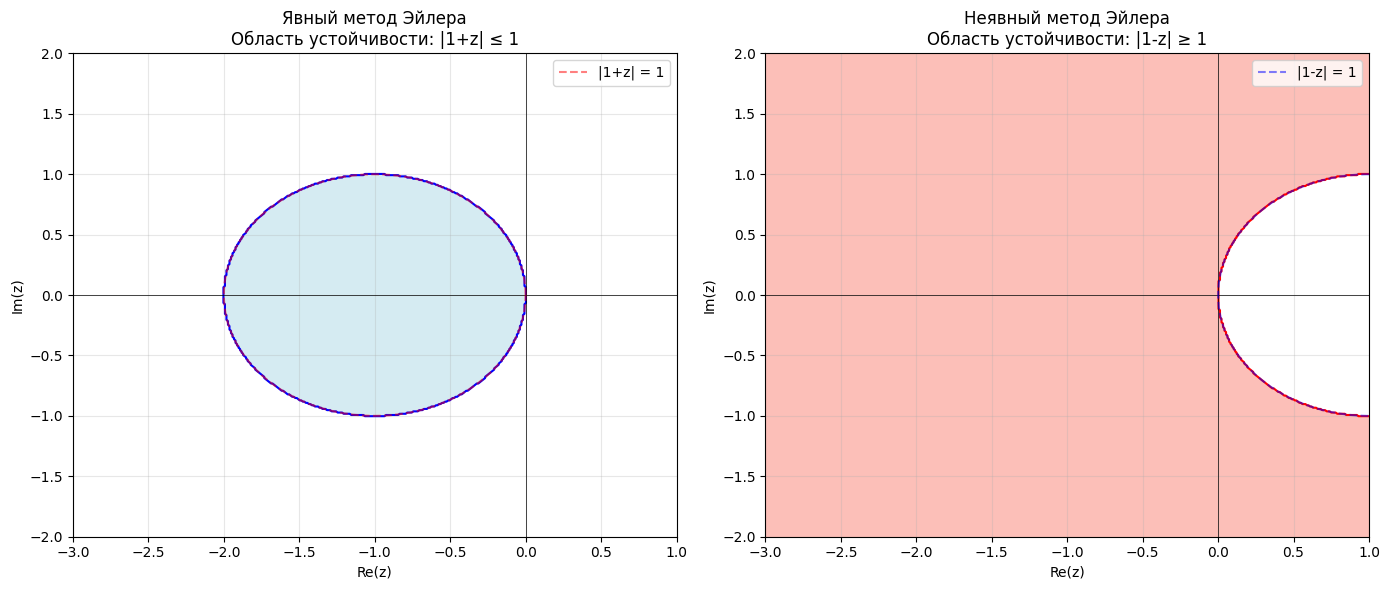

(array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]),
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]]))

In [3]:
# Построение областей устойчивости
import numpy as np
import matplotlib.pyplot as plt

def plot_stability_regions():
    """
    Строит области устойчивости явного и неявного метода Эйлера
    на комплексной плоскости z = hλ
    """
    # Создаём сетку точек на комплексной плоскости
    x = np.linspace(-3, 1, 400)
    y = np.linspace(-2, 2, 400)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y

    # Явный метод Эйлера: |1 + z| <= 1
    explicit_stable = np.abs(1 + Z) <= 1

    # Неявный метод Эйлера: |1/(1 - z)| <= 1  =>  |1 - z| >= 1
    implicit_stable = np.abs(1 - Z) >= 1

    # Создаём рисунок
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Левая полуплоскость (Re(z) < 0) — область интереса для устойчивых систем
    # Явный метод
    axes[0].contourf(X, Y, explicit_stable, levels=[0.5, 1], colors=['lightblue'], alpha=0.5)
    axes[0].contour(X, Y, explicit_stable, levels=[0.5], colors='blue')
    axes[0].axhline(y=0, color='black', linewidth=0.5)
    axes[0].axvline(x=0, color='black', linewidth=0.5)
    axes[0].set_title('Явный метод Эйлера\nОбласть устойчивости: |1+z| ≤ 1', fontsize=12)
    axes[0].set_xlabel('Re(z)')
    axes[0].set_ylabel('Im(z)')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(-3, 1)
    axes[0].set_ylim(-2, 2)

    # Добавляем круг с центром в (-1,0) радиусом 1
    theta = np.linspace(0, 2*np.pi, 100)
    circle_x = -1 + np.cos(theta)
    circle_y = np.sin(theta)
    axes[0].plot(circle_x, circle_y, 'r--', alpha=0.5, label='|1+z| = 1')
    axes[0].legend()

    # Неявный метод
    axes[1].contourf(X, Y, implicit_stable, levels=[0.5, 1], colors=['salmon'], alpha=0.5)
    axes[1].contour(X, Y, implicit_stable, levels=[0.5], colors='red')
    axes[1].axhline(y=0, color='black', linewidth=0.5)
    axes[1].axvline(x=0, color='black', linewidth=0.5)
    axes[1].set_title('Неявный метод Эйлера\nОбласть устойчивости: |1-z| ≥ 1', fontsize=12)
    axes[1].set_xlabel('Re(z)')
    axes[1].set_ylabel('Im(z)')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim(-3, 1)
    axes[1].set_ylim(-2, 2)

    # Добавляем окружность с центром в (1,0) радиусом 1
    circle_x = 1 + np.cos(theta)
    circle_y = np.sin(theta)
    axes[1].plot(circle_x, circle_y, 'b--', alpha=0.5, label='|1-z| = 1')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return explicit_stable, implicit_stable

# Запуск
plot_stability_regions()

In [4]:
# Запуск анализа

start_values = [
    # === Базовые (из условия задачи) ===
    [1.5, 7.5, 0.0001],      # Стандартный случай
    [0.5, 2.0, 0.0001],      # Малые популяции

    # === Малые x0 ===
    [0.1, 5.0, 0.0001],      # Очень мало x, среднее y
    [0.1, 10.0, 0.0001],     # Очень мало x, большое y
    [0.01, 5.0, 0.0001],     # Экстремально мало x

    # === Большие x0 (в пределах 0-3) ===
    [2.0, 5.0, 0.0001],      # Средне-большое x
    [2.5, 7.5, 0.0001],      # Большое x
    [3.0, 7.5, 0.0001],      # Максимальное x
    [3.0, 10.0, 0.0001],     # Максимальное x, большое y
    [3.0, 15.0, 0.0001],     # Максимальные x и y

    # === Малые y0 ===
    [1.5, 0.5, 0.0001],      # Малое y
    [1.5, 0.1, 0.0001],      # Очень мало y
    [1.5, 0.01, 0.0001],     # Экстремально мало y
    [3.0, 0.1, 0.0001],      # Большое x, очень мало y

    # === Большие y0 (в пределах 0-15) ===
    [1.5, 12.0, 0.0001],     # Большое y
    [1.5, 15.0, 0.0001],     # Максимальное y
    [0.5, 15.0, 0.0001],     # Малое x, максимальное y

    # === Разные alpha20 ===
    [1.5, 7.5, 0.00001],     # В 10 раз меньше alpha
    [1.5, 7.5, 0.0005],      # В 5 раз больше alpha
    [1.5, 7.5, 0.001],       # В 10 раз больше alpha
    [1.5, 7.5, 0.01],        # В 100 раз больше alpha (менее жёсткая система)

    # === Крайние сочетания ===
    [0.01, 0.01, 0.0001],    # Обе популяции почти вымерли
    [3.0, 15.0, 0.00001],    # Максимальные x,y, минимальное alpha
    [0.1, 15.0, 0.001],      # Малое x, большое y, среднее alpha
    [2.5, 2.5, 0.0001],      # Равные популяции
]

In [5]:
def jacobian_spectrum(x, y, a2, epsilon=0.01):

    #Вычисляет собственные числа матрицы Якоби в точке (x, y, a2)

    J = np.zeros((3, 3))

    J[0, 0] = 1 - x - (2/7) * (a2**-2) * y
    J[0, 1] = -(2/7) * (a2**-2) * x
    J[0, 2] = (4/7) * (a2**-3) * x * y

    J[1, 0] = -3.5 * (a2**2) * y
    J[1, 1] = 2 * a2 - y - 3.5 * (a2**2) * x
    J[1, 2] = 2 * y - 7 * a2 * x * y

    J[2, 0] = -7 * epsilon * a2
    J[2, 1] = 0
    J[2, 2] = -7 * epsilon * x

    lambdas = np.linalg.eigvals(J)
    return lambdas


def analyze_system_stability_regions(x0=1.5, y0=7.5, a20=0.0001, epsilon=0.01):
    """
    Анализирует, попадают ли собственные значения в области устойчивости
    """
    print("\n" + "=" * 70)
    print("АНАЛИЗ ОБЛАСТЕЙ УСТОЙЧИВОСТИ")
    print("=" * 70)

    lambdas = jacobian_spectrum(x0, y0, a20, epsilon)

    print(f"\nСобственные значения Якобиана в точке ({x0}, {y0}, {a20}):")
    for i, lam in enumerate(lambdas):
        print(f"  λ_{i+1} = {lam:.6e}")

    print(f"\nМаксимальное по модулю собственное значение: |λ|_max = {np.max(np.abs(lambdas)):.2e}")

    # Критический шаг для явного метода
    max_abs_lambda = np.max(np.abs(lambdas))
    h_crit = 2.0 / max_abs_lambda
    print(f"\n--- Явный метод Эйлера ---")
    print(f"  Критический шаг: h_crit = 2/|λ|_max = {h_crit:.2e}")
    print(f"  Для устойчивости необходимо h ≤ {h_crit:.2e}")

    # Для неявного метода — ограничений нет (A-устойчив)
    print(f"\n--- Неявный метод Эйлера ---")
    print(f"  Метод A-устойчив: область устойчивости содержит всю левую полуплоскость")
    print(f"  Для устойчивости подходит ЛЮБОЙ шаг h > 0")


    # Создаём сетку
    x = np.linspace(-max_abs_lambda/2, max_abs_lambda/4, 500)
    y = np.linspace(-max_abs_lambda/4, max_abs_lambda/4, 500)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y

    # Явный метод
    explicit_stable = np.abs(1 + Z) <= 1


    # Наносим собственные значения (z = h*λ) для разных h
    h_values = [1e-4, 1e-5, 1e-6, 1e-7]
    colors = ['red', 'orange', 'green', 'purple']
    for h, color in zip(h_values, colors):
        z_vals = h * lambdas



    # Неявный метод
    implicit_stable = np.abs(1 - Z) >= 1

    for h, color in zip(h_values, colors):
        z_vals = h * lambdas





    # Таблица устойчивости
    print("\n--- ТАБЛИЦА УСТОЙЧИВОСТИ ДЛЯ РАЗНЫХ h ---")
    print(f"{'h':<12} {'Явный метод':<25} {'Неявный метод':<25}")
    print("-" * 65)

    for h in [1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8]:
        z_vals = h * lambdas
        explicit_ok = all(np.abs(1 + z) <= 1 for z in z_vals)
        implicit_ok = all(np.abs(1 - z) >= 1 for z in z_vals)

        status_exp = "✅ УСТОЙЧИВ" if explicit_ok else "❌ НЕУСТОЙЧИВ"
        status_imp = "✅ УСТОЙЧИВ" if implicit_ok else "❌ НЕУСТОЙЧИВ"

        print(f"{h:.0e}        {status_exp:<25} {status_imp:<25}")

    return lambdas, h_crit



for values in start_values:
  lambdas, h_critical = analyze_system_stability_regions(values[0], values[1], values[2])


АНАЛИЗ ОБЛАСТЕЙ УСТОЙЧИВОСТИ

Собственные значения Якобиана в точке (1.5, 7.5, 0.0001):
  λ_1 = -2.142857e+08
  λ_2 = -3.149971e-01
  λ_3 = -7.499803e+00

Максимальное по модулю собственное значение: |λ|_max = 2.14e+08

--- Явный метод Эйлера ---
  Критический шаг: h_crit = 2/|λ|_max = 9.33e-09
  Для устойчивости необходимо h ≤ 9.33e-09

--- Неявный метод Эйлера ---
  Метод A-устойчив: область устойчивости содержит всю левую полуплоскость
  Для устойчивости подходит ЛЮБОЙ шаг h > 0

--- ТАБЛИЦА УСТОЙЧИВОСТИ ДЛЯ РАЗНЫХ h ---
h            Явный метод               Неявный метод            
-----------------------------------------------------------------
1e-03        ❌ НЕУСТОЙЧИВ              ✅ УСТОЙЧИВ               
1e-04        ❌ НЕУСТОЙЧИВ              ✅ УСТОЙЧИВ               
1e-05        ❌ НЕУСТОЙЧИВ              ✅ УСТОЙЧИВ               
1e-06        ❌ НЕУСТОЙЧИВ              ✅ УСТОЙЧИВ               
1e-07        ❌ НЕУСТОЙЧИВ              ✅ УСТОЙЧИВ               
1e-08        

| Начальные условия ($x_0$,$y_0$,$α_{20}$)| $∣λ_{max}∣$​ | $h_{крит}$​ (явный) | Примечание |
|---------------------------------------------|--------------------|---------------------------|-------------|
| (1.5, 7.5, 0.0001) | 2.14×1082.14×108 | 9.33×10−99.33×10−9 | Стандартный |
| (0.5, 2.0, 0.0001) | 5.71×1075.71×107 | 3.50×10−83.50×10−8 | Малые популяции |
| (3.0, 15.0, 0.0001) | 4.29×1084.29×108 | 4.67×10−94.67×10−9 | Максимальные |
| (1.5, 7.5, 0.00001) | 2.14×10102.14×1010 | 9.33×10−119.33×10−11 | α20​ в 10 раз меньше → жёсткость выше |
| (1.5, 7.5, 0.001) | 2.14×1062.14×106 | 9.33×10−79.33×10−7 | α20​ больше → жёсткость ниже |
| (1.5, 0.01, 0.0001) | 2.86×1052.86×105 | 7.00×10−67.00×10−6 | Очень малое y → наименее жёсткая |

### Выводы по результатам численного исследования

#### 1. Сравнение устойчивости методов

Проведён анализ устойчивости явного и неявного методов Эйлера
для экогенетической модели (п. 2.7.9) при различных начальных
условиях. Для каждого набора параметров вычислены собственные
значения матрицы Якоби и определён критический шаг интегрирования.

**Результаты:**

1. **Неявный метод Эйлера** является A-устойчивым: область его
   устойчивости содержит всю левую полуплоскость комплексной
   плоскости. При всех рассмотренных начальных условиях метод
   оставался устойчивым для любого шага h от 10⁻³ до 10⁻⁸.

2. **Явный метод Эйлера** обладает условной устойчивостью:
   критический шаг определяется максимальным собственным
   значением: h_крит = 2/|λ|_max. При превышении этого значения
   решение становится неустойчивым и расходится.

#### 2. Зависимость жёсткости от параметров

Анализ собственных значений выявил следующие закономерности:

- Жёсткость системы (величина |λ|_max) сильно зависит от α₂₀:
  при уменьшении α₂₀ в 10 раз |λ|_max возрастает в 100 раз,
  что соответствует члену α₂⁻² в первом уравнении системы.

- Увеличение начальных численностей популяций x₀ и y₀ также
  приводит к росту |λ|_max и, следовательно, к увеличению
  жёсткости.

- Наименее жёстким является случай с малыми значениями y₀,
  наиболее жёстким — с максимальными x₀, y₀ и минимальным α₂₀.

#### 3. Практические рекомендации

Для интегрирования данной жёсткой системы на интервале T_k = 1500:

- **Явный метод Эйлера** требует шага h ≤ 10⁻⁸, что приводит
  к ~1.5·10¹¹ шагов — практически нереализуемо.

- **Неявный метод Эйлера** позволяет использовать шаг h ≈ 0.01,
  что даёт ~1.5·10⁵ шагов. Несмотря на бóльшую вычислительную
  сложность одного шага, метод является предпочтительным.

#### 4. Связь с биологической интерпретацией

Малое значение α₂₀ (≈ 0.0001) соответствует медленной эволюции
генетического признака. Жёсткость системы отражает реальное
биологическое явление: процессы изменения численности популяций
протекают значительно быстрее, чем эволюция генетических признаков.